# Pricer d'options : démonstration

Ce notebook reprend les cinq onglets de produits du classeur Excel/VBA d'origine et compare les
résultats Python aux valeurs de référence de l'Excel. Il montre aussi la convergence
des méthodes numériques.

| Section | Méthodes |
|---|---|
| 1. Européennes | Black-Scholes-Merton, grecques, Monte-Carlo (standard, antithétique, contrôle) |
| 2. Américaines | Arbre CRR, correction par variable de contrôle, Longstaff-Schwartz |
| 3. Asiatiques | Géométrique exacte, Monte-Carlo arithmétique avec contrôle |
| 4. Barrières | Reiner-Rubinstein, Monte-Carlo pont brownien et discret |
| 5. Stratégies | Primes et grecques de position, points morts, scénario, comparatif |
| 6. Générateurs | PCG64 (NumPy) et MRG32k3a (identique au VBA) |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # rend le paquet `pricer` importable

import matplotlib.pyplot as plt
import numpy as np

from pricer import (
    americaine_crr_controle,
    arbre_crr,
    asiatique_geometrique,
    grecques_bsm,
    mc_asiatique,
    mc_barriere,
    mc_europeenne,
    parite_call_put,
    parites_barriere,
    prix_barriere,
    prix_barrieres,
    prix_bsm,
    prix_lsm,
)
from pricer.barrier import NOMS_BARRIERE, TYPES_BARRIERE, barriere_ajustee_bgk
from pricer.monte_carlo import convergence_europeenne

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3})
GRAINE = 42
EURO = dict(S=100.0, K=100.0, r=0.05, q=0.02, vol=0.20, T=1.0)
AMER = dict(S=40.0, K=40.0, r=0.06, q=0.0, vol=0.20, T=1.0)
BARR = dict(S=100.0, K=100.0, H=90.0, r=0.05, q=0.02, vol=0.25, T=1.0)


def tableau(lignes, entetes, formats=None):
    # Affiche un petit tableau aligné (sans dépendance à pandas).
    formats = formats or {}
    texte = [[formats.get(i, "{}").format(v) for i, v in enumerate(ligne)] for ligne in lignes]
    largeurs = [max(len(str(h)), *(len(t[i]) for t in texte)) for i, h in enumerate(entetes)]
    print("  ".join(str(h).ljust(w) for h, w in zip(entetes, largeurs, strict=True)))
    print("  ".join("-" * w for w in largeurs))
    for t in texte:
        print("  ".join(v.ljust(w) for v, w in zip(t, largeurs, strict=True)))

## 1. Options européennes

### 1.1 Black-Scholes-Merton et parité call-put

$$C = S e^{-qT}N(d_1) - K e^{-rT}N(d_2), \qquad d_{1,2} = \frac{\ln(S/K) + (r - q \pm \sigma^2/2)T}{\sigma\sqrt{T}}$$

In [2]:
call, put = prix_bsm(**EURO, option="call"), prix_bsm(**EURO, option="put")
print(f"Call BSM = {call:.6f}   (Excel : 9,227006)")
print(f"Put  BSM = {put:.6f}   (Excel : 6,330081)")
print(f"Parité C − P − (S e^(−qT) − K e^(−rT)) = {parite_call_put(**EURO):.1e}")

Call BSM = 9.227006   (Excel : 9,227006)
Put  BSM = 6.330081   (Excel : 6,330081)
Parité C − P − (S e^(−qT) − K e^(−rT)) = 0.0e+00


### 1.2 Grecques (vega et rho pour +1 point, theta par jour)

In [3]:
gc, gp = grecques_bsm(**EURO, option="call"), grecques_bsm(**EURO, option="put")
tableau(
    [(k, gc.en_dict()[k], gp.en_dict()[k]) for k in gc.en_dict()],
    ["Grecque", "Call", "Put"],
    {1: "{:+.6f}", 2: "{:+.6f}"},
)

Grecque  Call       Put      
-------  ---------  ---------
delta    +0.586851  -0.393348
gamma    +0.018951  +0.018951
vega     +0.379012  +0.379012
theta    -0.013943  -0.006284
rho      +0.494581  -0.456648


Delta et gamma en fonction du spot :

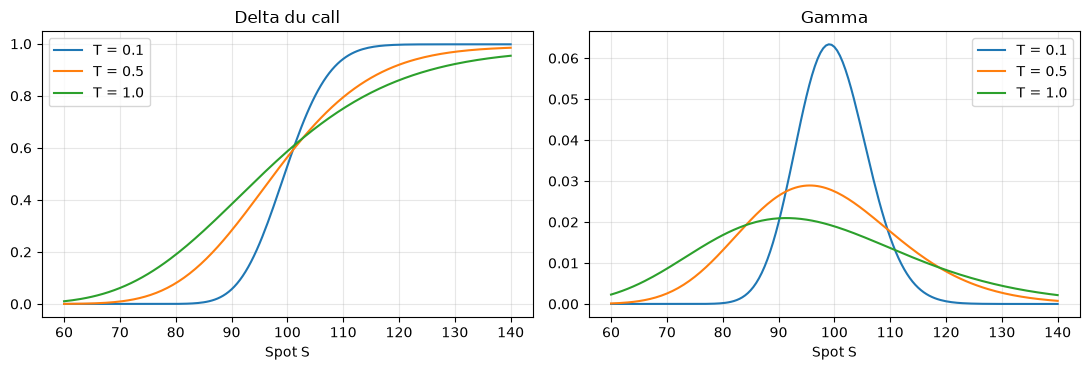

In [4]:
spots = np.linspace(60, 140, 161)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for T in (0.1, 0.5, 1.0):
    p = {**EURO, "T": T}
    a1.plot(spots, [grecques_bsm(**{**p, "S": s}).delta for s in spots], label=f"T = {T}")
    a2.plot(spots, [grecques_bsm(**{**p, "S": s}).gamma for s in spots], label=f"T = {T}")
a1.set(title="Delta du call", xlabel="Spot S")
a2.set(title="Gamma", xlabel="Spot S")
a1.legend()
a2.legend()
plt.tight_layout()
plt.show()

### 1.3 Monte-Carlo : trois estimateurs

- **Standard** : moyenne des payoffs actualisés.
- **Antithétique** : moyenne de $f(Z)$ et $f(-Z)$.
- **Variable de contrôle** : $X = e^{-rT}S_T$, d'espérance connue $S e^{-qT}$, avec $\beta^*$ estimé.

In [5]:
res = mc_europeenne(**EURO, n_sim=100_000, graine=GRAINE)
tableau(
    [
        (
            ligne["option"],
            ligne["méthode"],
            ligne["prix"],
            ligne["SE"],
            ligne["IC95 bas"],
            ligne["IC95 haut"],
            ligne["z"],
        )
        for ligne in res.lignes()
    ],
    ["Option", "Méthode", "Prix", "SE", "IC bas", "IC haut", "z"],
    {2: "{:.6f}", 3: "{:.6f}", 4: "{:.4f}", 5: "{:.4f}", 6: "{:+.2f}"},
)
print()
for k, v in res.diagnostics.items():
    print(f"{k:22s} {v: .4f}")

Option  Méthode       Prix      SE        IC bas  IC haut  z    
------  ------------  --------  --------  ------  -------  -----
call    standard      9.201616  0.043963  9.1154  9.2878   -0.58
call    antithetique  9.250591  0.023236  9.2050  9.2961   +1.02
call    controle      9.244541  0.018096  9.2091  9.2800   +0.97
put     standard      6.372050  0.029114  6.3150  6.4291   +1.44
put     antithetique  6.338932  0.014904  6.3097  6.3681   +0.59
put     controle      6.347616  0.018096  6.3121  6.3831   +0.97

beta_call               0.6373
beta_put               -0.3627
corr_call               0.9114
corr_put               -0.7834
gain_cv_call            5.9022
efficacite_av_call      1.7899
gain_cv_put             2.5885
efficacite_av_put       1.9079


### 1.4 Convergence en $1/\sqrt{N}$

À gauche, l'estimation et son IC à 95 % se resserrent autour de BSM. À droite, en échelle
log-log, la SE suit une droite de pente $-1/2$ : diviser l'erreur par 10 demande 100 fois
plus de simulations. Les techniques de réduction de variance déplacent la droite vers le bas
sans en changer la pente.

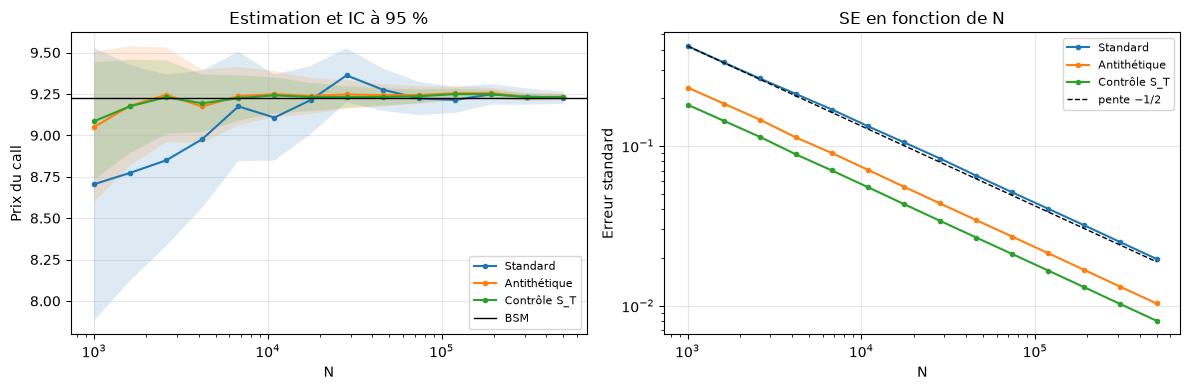

In [6]:
tailles = np.unique(np.round(np.logspace(3, np.log10(500_000), 14)).astype(int))
conv = convergence_europeenne(**EURO, tailles=tailles, option="call", graine=GRAINE)
noms = {"standard": "Standard", "antithetique": "Antithétique", "controle": "Contrôle S_T"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for m, nom in noms.items():
    p, se = conv[f"prix_{m}"], conv[f"se_{m}"]
    a1.plot(conv["n"], p, "o-", ms=3, label=nom)
    a1.fill_between(conv["n"], p - 1.96 * se, p + 1.96 * se, alpha=0.15)
    a2.loglog(conv["n"], se, "o-", ms=3, label=nom)
a1.axhline(call, color="k", lw=1, label="BSM")
a1.set(xscale="log", xlabel="N", ylabel="Prix du call", title="Estimation et IC à 95 %")
ref = conv["se_standard"][0] * np.sqrt(conv["n"][0] / conv["n"])
a2.loglog(conv["n"], ref, "k--", lw=1, label="pente −1/2")
a2.set(xlabel="N", ylabel="Erreur standard", title="SE en fonction de N")
a1.legend(fontsize=8)
a2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Options américaines

### 2.1 Arbre CRR et correction par variable de contrôle

$$V^{am}_{CV} = V^{am}_{arbre} + \left(V^{eu}_{BSM} - V^{eu}_{arbre}\right)$$

In [7]:
am = americaine_crr_controle(**AMER, n_pas=1_000)
tableau(
    [
        ("Européenne BSM", am.bsm_call, am.bsm_put, "4,395820 / 2,066401"),
        ("Européenne arbre", am.arbre.euro_call, am.arbre.euro_put, "— / 2,065596"),
        ("Américaine arbre", am.arbre.amer_call, am.arbre.amer_put, "— / 2,319278"),
        ("Américaine CRR + CV", am.cv_call, am.cv_put, "4,395820 / 2,320083"),
    ],
    ["Méthode", "Call", "Put", "Excel (call / put)"],
    {1: "{:.6f}", 2: "{:.6f}"},
)
print(f"\nPrime d'exercice anticipé du put : {am.prime_put:.6f}")
print(f"Call américain − call européen (q = 0) : {am.arbre.amer_call - am.arbre.euro_call:.1e}")

Méthode              Call      Put       Excel (call / put) 
-------------------  --------  --------  -------------------
Européenne BSM       4.395820  2.066401  4,395820 / 2,066401
Européenne arbre     4.395014  2.065596  — / 2,065596       
Américaine arbre     4.395014  2.319278  — / 2,319278       
Américaine CRR + CV  4.395820  2.320083  4,395820 / 2,320083

Prime d'exercice anticipé du put : 0.253682
Call américain − call européen (q = 0) : 0.0e+00


### 2.2 Convergence de l'arbre

L'erreur de l'arbre européen face à BSM décroît en $O(1/n)$. Elle oscille, car la position
du strike entre deux nœuds change avec $n$. La correction par variable de contrôle retire
l'essentiel de cette erreur, qui est commune à l'européenne et à l'américaine.

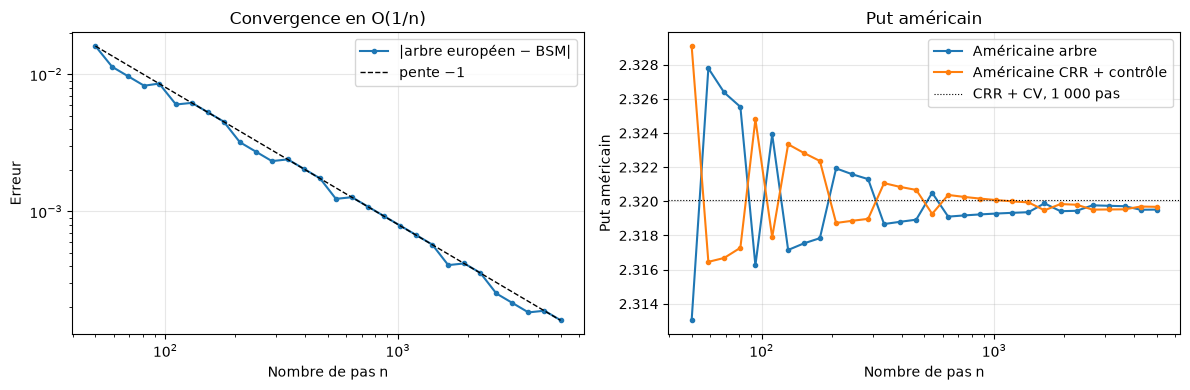

In [8]:
pas = np.unique(np.round(np.logspace(np.log10(50), np.log10(5000), 30)).astype(int))
arbres = [arbre_crr(**AMER, n_pas=int(n)) for n in pas]
err_eu = [abs(a.euro_put - am.bsm_put) for a in arbres]
am_brut = [a.amer_put for a in arbres]
am_cv = [a.amer_put + am.bsm_put - a.euro_put for a in arbres]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.loglog(pas, err_eu, "o-", ms=3, label="|arbre européen − BSM|")
a1.loglog(pas, err_eu[0] * pas[0] / pas, "k--", lw=1, label="pente −1")
a1.set(xlabel="Nombre de pas n", ylabel="Erreur", title="Convergence en O(1/n)")
a2.plot(pas, am_brut, "o-", ms=3, label="Américaine arbre")
a2.plot(pas, am_cv, "o-", ms=3, label="Américaine CRR + contrôle")
a2.axhline(am.cv_put, color="k", lw=0.8, ls=":", label="CRR + CV, 1 000 pas")
a2.set(xscale="log", xlabel="Nombre de pas n", ylabel="Put américain", title="Put américain")
a1.legend()
a2.legend()
plt.tight_layout()
plt.show()

### 2.3 Longstaff-Schwartz

On utilise 50 dates d'exercice, 20 000 chemins antithétiques et une régression cubique en
$x = S/K - 1$ sur les chemins dans la monnaie.

LSM put  = 2.325782 ± 0.0233  (Excel : 2,310722, SE 0,0118)
LSM call = 4.382727 ± 0.0560
Écart LSM − (CRR + CV), put : +0.48 SE


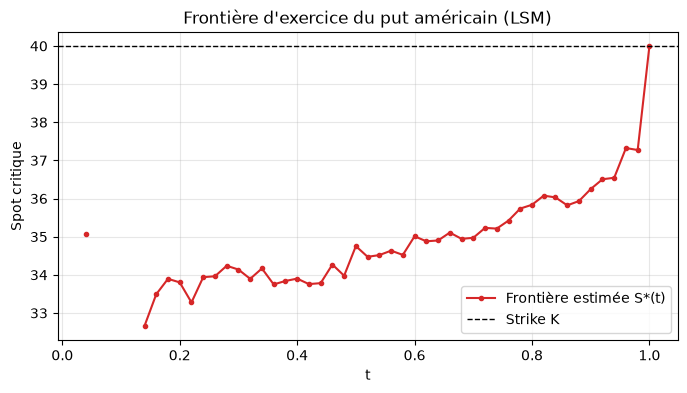

In [9]:
lsm_p = prix_lsm(**AMER, option="put", n_sim=20_000, n_dates=50, graine=GRAINE)
lsm_c = prix_lsm(**AMER, option="call", n_sim=20_000, n_dates=50, graine=GRAINE)
print(f"LSM put  = {lsm_p.prix:.6f} ± {1.96 * lsm_p.se:.4f}  (Excel : 2,310722, SE 0,0118)")
print(f"LSM call = {lsm_c.prix:.6f} ± {1.96 * lsm_c.se:.4f}")
print(f"Écart LSM − (CRR + CV), put : {lsm_p.z_score(am.cv_put):+.2f} SE")
fig, ax = plt.subplots()
ax.plot(lsm_p.temps, lsm_p.frontiere, "o-", ms=3, color="C3", label="Frontière estimée S*(t)")
ax.axhline(AMER["K"], color="k", ls="--", lw=1, label="Strike K")
ax.set(xlabel="t", ylabel="Spot critique", title="Frontière d'exercice du put américain (LSM)")
ax.legend()
plt.show()

Convergence du LSM avec le nombre de dates d'exercice. L'option bermudéenne tend vers l'américaine :

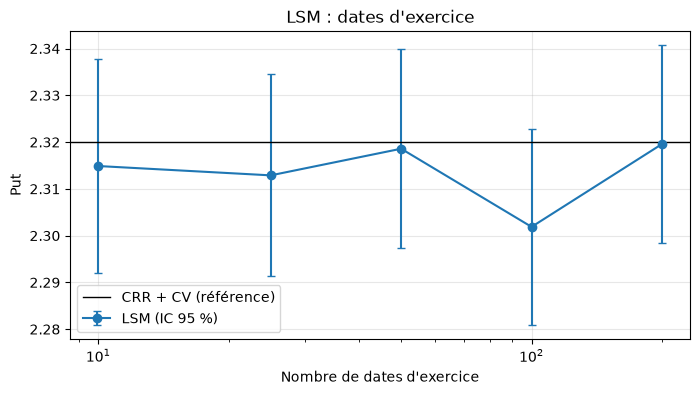

In [10]:
dates = [10, 25, 50, 100, 200]
vals = [prix_lsm(**AMER, option="put", n_sim=24_000, n_dates=d, graine=GRAINE) for d in dates]
fig, ax = plt.subplots()
ax.errorbar(
    dates,
    [v.prix for v in vals],
    yerr=[1.96 * v.se for v in vals],
    fmt="o-",
    capsize=3,
    label="LSM (IC 95 %)",
)
ax.axhline(am.cv_put, color="k", lw=1, label="CRR + CV (référence)")
ax.set(
    xscale="log", xlabel="Nombre de dates d'exercice", ylabel="Put", title="LSM : dates d'exercice"
)
ax.legend()
plt.show()

## 3. Options asiatiques (moyenne arithmétique, 12 fixings)

La moyenne géométrique est log-normale, donc son prix est exact. On l'utilise comme variable
de contrôle pour la moyenne arithmétique.

In [11]:
geo_c = asiatique_geometrique(**EURO, n_fixings=12, option="call")
geo_p = asiatique_geometrique(**EURO, n_fixings=12, option="put")
print(f"Géométrique exacte : call {geo_c:.6f} (Excel 5,327706) ; put {geo_p:.6f} (Excel 4,088834)")
res_as = mc_asiatique(**EURO, n_fixings=12, n_sim=50_000, graine=GRAINE)
tableau(
    [
        (
            ligne["option"],
            ligne["méthode"],
            ligne["prix"],
            ligne["SE"],
            "—" if np.isnan(ligne["z"]) else f"{ligne['z']:+.2f}",
        )
        for ligne in res_as.lignes()
    ],
    ["Option", "Méthode", "Prix", "SE", "z (géo)"],
    {2: "{:.6f}", 3: "{:.6f}"},
)
d = res_as.diagnostics
print(
    f"\nCorr(arithmétique, géométrique) = {d['corr_call']:.5f} ; "
    f"gain de variance call × {d['gain_cv_call']:.0f}, put × {d['gain_cv_put']:.0f}"
)
print("Excel : call contrôle 5,519595 (SE 0,00098), gains × 1 337 et × 1 539")

Géométrique exacte : call 5.327706 (Excel 5,327706) ; put 4.088834 (Excel 4,088834)
Option    Méthode       Prix      SE        z (géo)
--------  ------------  --------  --------  -------
call      standard      5.520317  0.036204  —      
call      antithetique  5.505762  0.018543  —      
call      controle      5.521452  0.000993  —      
put       standard      3.940992  0.025955  —      
put       antithetique  3.947642  0.013579  —      
put       controle      3.958137  0.000669  —      
geo_call  standard      5.326605  0.035115  -0.03  
geo_put   standard      4.071267  0.026586  -0.66  

Corr(arithmétique, géométrique) = 0.99962 ; gain de variance call × 1328, put × 1506
Excel : call contrôle 5,519595 (SE 0,00098), gains × 1 337 et × 1 539


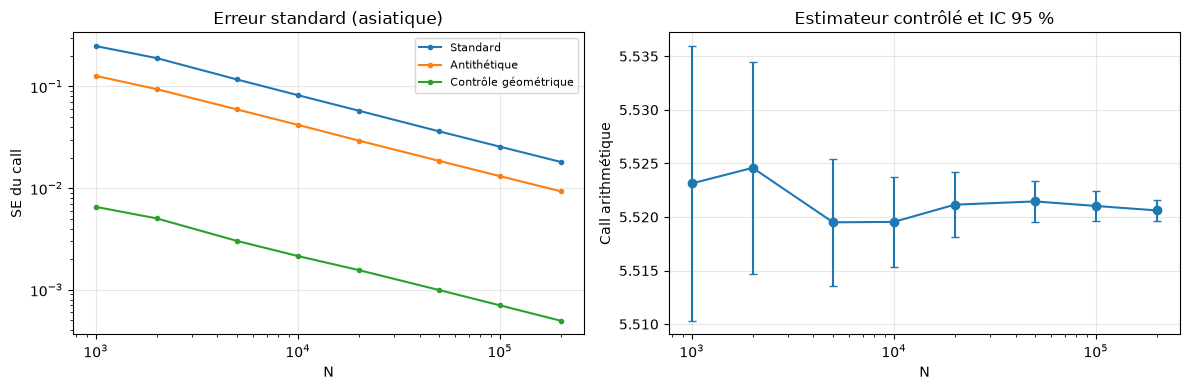

In [12]:
tailles = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000, 200_000]
se = {m: [] for m in ("standard", "antithetique", "controle")}
prix_cv = []
for n in tailles:
    r_n = mc_asiatique(**EURO, n_fixings=12, n_sim=n, graine=GRAINE)
    for m in se:
        se[m].append(r_n.estimations["call"][m].se)
    prix_cv.append(r_n.estimations["call"]["controle"].prix)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for m, nom in noms.items():
    a1.loglog(tailles, se[m], "o-", ms=3, label=nom.replace("S_T", "géométrique"))
a1.set(xlabel="N", ylabel="SE du call", title="Erreur standard (asiatique)")
a2.errorbar(tailles, prix_cv, yerr=1.96 * np.array(se["controle"]), fmt="o-", capsize=3)
a2.set(xscale="log", xlabel="N", ylabel="Call arithmétique", title="Estimateur contrôlé et IC 95 %")
a1.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Options barrières

### 4.1 Formules fermées et parités In + Out = vanille

In [13]:
EXCEL_BARR = dict(
    DOC=8.138811,
    DIC=2.984951,
    UOC=0.0,
    UIC=11.123762,
    DOP=0.086816,
    DIP=8.140021,
    UOP=0.0,
    UIP=8.226837,
)
fermees = prix_barrieres(**BARR)
tableau(
    [
        (NOMS_BARRIERE[c], fermees[c], EXCEL_BARR[c], fermees[c] - EXCEL_BARR[c])
        for c in TYPES_BARRIERE
    ],
    ["Type", "Python", "Excel (6 décimales)", "Écart"],
    {1: "{:.6f}", 2: "{:.6f}", 3: "{:+.1e}"},
)
print()
for famille, ecart in parites_barriere(fermees).items():
    print(f"Parité {famille:9s} : {ecart:.1e}")

Type               Python     Excel (6 décimales)  Écart   
-----------------  ---------  -------------------  --------
Down-and-Out Call  8.138811   8.138811             -4.5e-07
Down-and-In Call   2.984951   2.984951             +3.8e-07
Up-and-Out Call    0.000000   0.000000             +0.0e+00
Up-and-In Call     11.123762  11.123762            -7.2e-08
Down-and-Out Put   0.086816   0.086816             +2.3e-07
Down-and-In Put    8.140021   8.140021             -1.9e-07
Up-and-Out Put     0.000000   0.000000             +0.0e+00
Up-and-In Put      8.226837   8.226837             +4.7e-08

Parité Down Call : 0.0e+00
Parité Up Call   : 0.0e+00
Parité Down Put  : 0.0e+00
Parité Up Put    : 0.0e+00


### 4.2 Monte-Carlo avec correction de pont brownien (surveillance continue)

In [14]:
res_b = mc_barriere(**BARR, n_pas=252, surveillance="continue", n_sim=50_000, graine=GRAINE)
tableau(
    [
        (
            NOMS_BARRIERE[c],
            fermees[c],
            res_b.estimations[c]["continue"].prix,
            res_b.estimations[c]["continue"].se,
            res_b.z_scores()[c]["continue"],
        )
        for c in TYPES_BARRIERE
    ],
    ["Type", "Formule", "MC", "SE", "z"],
    {1: "{:.6f}", 2: "{:.6f}", 3: "{:.5f}", 4: "{:+.2f}"},
)

Type               Formule    MC         SE       z    
-----------------  ---------  ---------  -------  -----
Down-and-Out Call  8.138811   8.118455   0.04630  -0.44
Down-and-In Call   2.984951   2.983666   0.02489  -0.05
Up-and-Out Call    0.000000   0.000000   0.00000  +0.00
Up-and-In Call     11.123762  11.102122  0.04318  -0.50
Down-and-Out Put   0.086816   0.083476   0.00186  -1.80
Down-and-In Put    8.140021   8.121780   0.02525  -0.72
Up-and-Out Put     0.000000   0.000000   0.00000  +0.00
Up-and-In Put      8.226837   8.205256   0.02479  -0.87


### 4.3 Surveillance discrète, pont brownien et correction de Broadie-Glasserman-Kou

Avec le pont brownien, l'estimateur n'a pas de biais quel que soit le nombre de pas. En
surveillance discrète, la Down-and-Out vaut plus que la formule continue, car on ne voit pas
les franchissements entre deux dates. La barrière décalée de BGK,
$H e^{-0{,}5826\,\sigma\sqrt{\Delta t}}$, explique cet écart.

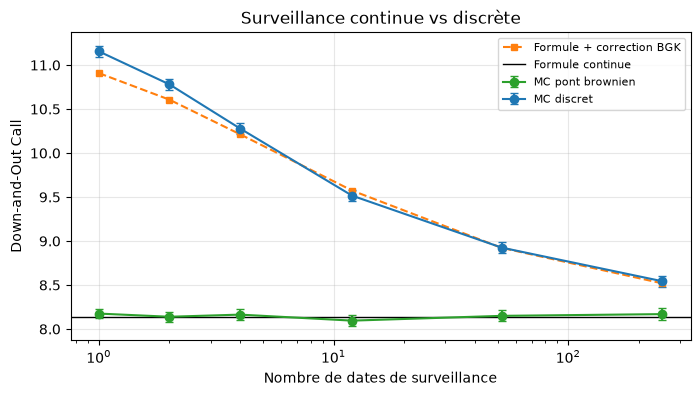

In [15]:
pas = [1, 2, 4, 12, 52, 252]
fig, ax = plt.subplots()
for mode, couleur in (("continue", "C2"), ("discrete", "C0")):
    v = [
        mc_barriere(**BARR, n_pas=m, surveillance=mode, n_sim=100_000, graine=GRAINE).estimations[
            "DOC"
        ][mode]
        for m in pas
    ]
    ax.errorbar(
        pas,
        [x.prix for x in v],
        yerr=[1.96 * x.se for x in v],
        fmt="o-",
        capsize=3,
        color=couleur,
        label="MC " + ("pont brownien" if mode == "continue" else "discret"),
    )
bgk = [
    prix_barriere(**{**BARR, "H": barriere_ajustee_bgk(90, 100, 0.25, 1, m)}, type_barriere="DOC")
    for m in pas
]
ax.plot(pas, bgk, "s--", color="C1", ms=4, label="Formule + correction BGK")
ax.axhline(fermees["DOC"], color="k", lw=1, label="Formule continue")
ax.set(
    xscale="log",
    xlabel="Nombre de dates de surveillance",
    ylabel="Down-and-Out Call",
    title="Surveillance continue vs discrète",
)
ax.legend(fontsize=8)
plt.show()

## 5. Stratégies et grecques de position

Cette section reprend l'onglet « Stratégies & Grecques » avec les paramètres par défaut :
S = 100, r = 5 %, q = 0, σ = 20 %, 100 jours, et un stellage (straddle) acheté au strike 100.

In [16]:
from pricer.strategies import (
    analyser_position,
    jambes_strategie,
    lecture_grecques,
    profils,
    scenario_pnl,
    tableau_comparatif,
)

MARCHE = dict(S=100.0, r=0.05, q=0.0, vol=0.20, jours=100)
straddle = jambes_strategie("Achat stellage (straddle)", K0=100, delta_k=10)
pos = analyser_position(straddle, **MARCHE)
print(f"Coût net {pos.cout_net:.10f} (Excel 8,3628572479)")
print({k: round(v, 10) for k, v in pos.grecques().items()})
print(
    "Points morts :",
    [round(x, 4) for x in pos.points_morts],
    "| gain max :",
    pos.gain_max,
    "| perte max :",
    round(pos.perte_max, 4),
)
for phrase in lecture_grecques(pos, **MARCHE):
    print("•", phrase)
sc = scenario_pnl(straddle, **MARCHE, jours_ecoules=30, vol_scenario=0.20, spot_scenario=100)
print(
    f"\nScénario J+30 : theta {sc.contribution_theta:.6f} ; P&L réel {sc.pnl_reel:.6f} ; "
    f"écart {sc.ecart:.6f} (Excel −1,25741451 / −1,3685070859)"
)

Coût net 8.3628572479 (Excel 8,3628572479)
{'delta': 0.145357629, 'gamma': 0.0749494896, 'vega': 0.4106821348, 'theta': -0.041913817, 'rho': 0.0169120703}
Points morts : [91.6371, 108.3629] | gain max : inf | perte max : -8.3629
• Delta 0,15 : gagne ≈ 0,15 € si le sous-jacent monte de 1 € — biais haussier faible.
• Gamma 0,0749 > 0 : acheteur de convexité — les grands mouvements jouent en faveur de la position.
• Vega 0,411 : gagne ≈ 0,41 € si la volatilité implicite monte d'1 point (acheteur de volatilité).
• Theta -0,042 : perd ≈ 0,042 € par jour si rien ne bouge (le temps joue contre la position).
• Synthèse : acheteur de volatilité — paie le temps (Theta) pour profiter des mouvements (Gamma, Vega).

Scénario J+30 : theta -1.257415 ; P&L réel -1.368507 ; écart -0.111093 (Excel −1,25741451 / −1,3685070859)


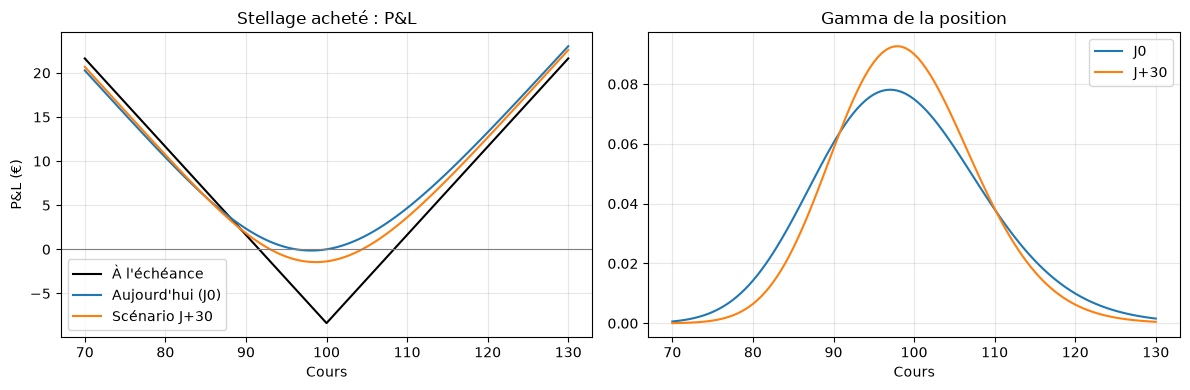

In [17]:
pr = profils(straddle, **MARCHE, jours_ecoules=30, vol_scenario=0.20, grecque="gamma")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(pr["spots"], pr["pnl_echeance"], "k", lw=1.5, label="À l'échéance")
a1.plot(pr["spots"], pr["pnl_j0"], label="Aujourd'hui (J0)")
a1.plot(pr["spots"], pr["pnl_scenario"], label="Scénario J+30")
a1.axhline(0, color="grey", lw=0.8)
a1.set(xlabel="Cours", ylabel="P&L (€)", title="Stellage acheté : P&L")
a2.plot(pr["spots"], pr["grecque_j0"], label="J0")
a2.plot(pr["spots"], pr["grecque_scenario"], label="J+30")
a2.set(xlabel="Cours", title="Gamma de la position")
a1.legend()
a2.legend()
plt.tight_layout()
plt.show()

Tableau comparatif des 16 stratégies aux mêmes paramètres :

In [18]:
tableau(
    [
        (li["stratégie"], li["coût net"], li["delta"], li["gamma"], li["vega"], li["theta"])
        for li in tableau_comparatif(**MARCHE)
    ],
    ["Stratégie", "Coût net", "Delta", "Gamma", "Vega", "Theta"],
    {i: "{:+.5f}" for i in range(1, 6)},
)

Stratégie                        Coût net  Delta     Gamma     Vega      Theta   
-------------------------------  --------  --------  --------  --------  --------
Achat call                       +4.86169  +0.57268  +0.03747  +0.20534  -0.02771
Vente call                       -4.86169  -0.57268  -0.03747  -0.20534  +0.02771
Achat put                        +3.50117  -0.42732  +0.03747  +0.20534  -0.01420
Vente put                        -3.50117  +0.42732  -0.03747  -0.20534  +0.01420
Achat spread (bull call spread)  +3.50418  +0.33914  +0.00822  +0.04505  -0.00867
Vente spread (bear call spread)  -3.50418  -0.33914  -0.00822  -0.04505  +0.00867
Achat tunnel                     +1.04861  +0.63906  +0.00623  +0.03415  -0.01203
Vente tunnel                     -1.04861  -0.63906  -0.00623  -0.03415  +0.01203
Achat stellage (straddle)        +8.36286  +0.14536  +0.07495  +0.41068  -0.04191
Vente stellage (straddle)        -8.36286  -0.14536  -0.07495  -0.41068  +0.04191
Achat strangle  

## 6. Générateurs : PCG64 et MRG32k3a

MRG32k3a reproduit la suite du VBA. La version vectorisée par saut en avant donne exactement
les mêmes tirages que la boucle séquentielle :

In [19]:
from pricer.rng import MRG32k3a

a, b = MRG32k3a(2024), MRG32k3a(2024)
print(
    "Vectorisé = séquentiel :",
    np.array_equal(a.uniformes(10_000), [b.uniforme() for _ in range(10_000)]),
)
for gen in ("pcg64", "mrg32k3a"):
    r_g = mc_europeenne(**EURO, n_sim=100_000, graine=GRAINE, generateur=gen)
    z = r_g.z_scores()["call"]
    print(f"{gen:9s} z call : " + ", ".join(f"{m} {v:+.2f}" for m, v in z.items()))

Vectorisé = séquentiel : True
pcg64     z call : standard -0.58, antithetique +1.02, controle +0.97
mrg32k3a  z call : standard +0.81, antithetique +0.61, controle +0.53


## Récapitulatif : Excel et Python

| Produit | Grandeur | Excel | Python |
|---|---|---|---|
| Européenne | Call / Put BSM | 9,227006 / 6,330081 | identiques (écart < 1e-9) |
| Américaine | Put CRR + CV (1 000 pas) | 2,320083 | 2,320083 |
| Américaine | Put LSM | 2,3107 (SE 0,012) | ≈ 2,31, à moins de 3 SE de CRR + CV |
| Asiatique | Géométrique call / put | 5,327706 / 4,088834 | identiques |
| Asiatique | Arithmétique call (contrôle) | 5,519595 (SE 0,001) | ≈ 5,5215 (SE 0,001) |
| Barrière | DOC / DIC | 8,138811 / 2,984951 | identiques |
| Stratégies | Straddle : coût / points morts | 8,3628572 / 91,6371 et 108,3629 | identiques |

Les résultats Monte-Carlo dépendent de la graine. Pour ces estimations, on vérifie que les
résultats restent statistiquement compatibles avec la valeur de référence ($|z| < 3$).